# progHW 3: Drawing conics

<a target="_blank" href="https://colab.research.google.com/github/p-adema/uva-linalg-26/blob/main/progHW3.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Important:
    * DO NOT import any packages unless explicitly asked.
    * ONLY work where "#. Your solution here..." is written. Nowhere else.
    * Do NOT change any function names, arguments, etc.
    * Please follow the hint instructions. If it is stated to not return anything, please strictly do not. Else the AutoTest will break.

The goal of this assignment is to implement a function `plot_conic(c1, c2, c3, c4, x_lim, y_lim)` which given an equation
$$
c_1 x^2 + c_2 y^2 + c_3 xy  = c_4
$$
plot the conic (which might be an ellipse or an hyperbola) associated with the equation. It is a generalization of the exercises you did during the first werkcollege of week $7$ (so it might also be easier to start the laptop assigment right after that werkcollege).

## Part 1: Computing the eigenvalues, the orthogonal matrix and identifying the type of the conic

As you may remember, in order to plot the conic, the first steps are:
1) find the matrix $A$ associated with the quadratic form

2) compute the eigenvalues of $A$ and the orthogonal matrix $Q$ diagonalizing $A$ (i.e. $Q^TAQ$ is a diagonal matrix containing the eigenvalues)

3) using the signs of the eigenvalues, determine if the conic is an ellipse, an horizontal hyperbola or a vertical hyperbola.

### Exercise 1 (0.25 pt): Finding the matrix associated with the quadratic form

We ask you to write a function `get_quadratic_form(c1, c2, c3)` returning the symmetric matrix $A$ (a numpy array) associated with the quadratric form $c_1 x^2 + c_2 y^2 + c_3 xy $. In other words, the quadratic form should be equal to $[x,y] A [x,y]^T$.

In [146]:
import numpy as np
import matplotlib.pyplot as plt
import math


def get_quadratic_form(c1, c2, c3):
    # Hint: Return the symmetric matrix in the form of a numpy array. Do NOT deviate from this.
    #. Your solution here ...
    return np.array([[float(c1), float(c3)/2], [float(c3)/2, float(c2)]])

You can run the cell below to test your code.

In [147]:
A = get_quadratic_form(2, 6, 8)
x = np.array([[1.,],[3.,]])
assert x.T @ A @ x == 80., 'Basic test failed'

print('Function seems to work')

Function seems to work


### Exercise 2 (0.5 pt): Computing the eigenvalues and the orthogonal matrix

We ask you to implement two functions: `get_eigenvalues(c1, c2, c3)` and `get_orthogonal_matrix(c1, c2, c3)`. The function `get_eigenvalues`should return a 1D numpy array containing the two eigenvalues of the matrix $A$ associated with the quadratric form $c_1 x^2 + c_2 y^2 + c_3 xy $ (in other words, $A$ is the matrix returned by the function `get_quadratic_form`).

The function `get_orthogonal_matrix` should return the numpy array representing the orthogonal matrix $Q$ diagonalizing $A$ (i.e. $Q^TAQ$ is a diagonal matrix containing the eigenvalues).

Hint. In order to compute the eigenvalues and $Q$, you can use any function from the module [np.linalg](https://numpy.org/doc/stable/reference/routines.linalg.html).

In [148]:
def get_eigenvalues(c1, c2, c3):
    # Hint: Return a 1D array containing two eigenvalues of matrix A. Do NOT deviate from this.
    #. Your solution here ...
    A = get_quadratic_form(c1, c2, c3)
    evals, Q = np.linalg.eigh(A)
    return evals

def get_orthogonal_matrix(c1, c2, c3):
    # Hint: Return the numpy array representing the orthogonal matrix Q. Do NOT deviate from this.
    #. Your solution here ...
    A = get_quadratic_form(c1, c2, c3)
    evals, Q = np.linalg.eigh(A)

    if Q[0, 0] > 0:
        Q[:, 0] = -Q[:, 0]

    if Q[0, 1] > 0:
        Q[:, 1] = -Q[:, 1]

    return Q

get_eigenvalues(3,3,-2)

array([2., 4.])

You can run the cell below to test your code.

In [149]:
assert np.allclose(get_eigenvalues(2, 6, 8),np.array([-0.47213595,  8.47213595])), 'Basic test failed for eigenvalues'

Q_actual = get_orthogonal_matrix(2, 6, 8)
Q_expected = np.array([[-0.85065081, -0.52573111],[ 0.52573111, -0.85065081]])

# Check if each column of Q_actual is either equal to the corresponding column in Q_expected
# or is equal to the negative of the corresponding column in Q_expected, to account for eigenvector sign ambiguity.
col0_match = np.allclose(Q_actual[:, 0], Q_expected[:, 0]) or np.allclose(Q_actual[:, 0], -Q_expected[:, 0])
col1_match = np.allclose(Q_actual[:, 1], Q_expected[:, 1]) or np.allclose(Q_actual[:, 1], -Q_expected[:, 1])

assert (col0_match and col1_match), 'Basic test failed for orthogonal matrix (sign mismatch)'

print('Functions seem to work')

Functions seem to work


### Exercise 3  (0.25 pt): Determining the type of the conic

Once you have the eigenvalues $\lambda_1, \lambda_2$ of $A$, then we know that if we perform the change of variable $[x,y]^T = Q[x',y']^T$, then the quadratic form becomes
$$
\lambda_1 x'^2 + \lambda_2y'^2 = c_4
$$
You may assume from now on that $c_4>0$ and that $\lambda_1, \lambda_2 >0$ (otherwise the equation does not admit any solution).

Using the signs of the eigenvalues, we can now determine the type of the conic. Remember that

* the canonical equation of an ellipse is of the form $\frac{x^2}{a^2} + \frac{y^2}{b^2} =1$

* the canonical equation of an horizontal hyperbola is of the form $\frac{x^2}{a^2} - \frac{y^2}{b^2} =1$

* the canonical equation of an vertical hyperbola is of the form $ -\frac{x^2}{a^2} + \frac{y^2}{b^2} =1$

Make sure to also have a look at Figure 5.15 in Poole (page 416).

We ask you to implement three functions `is_ellipse(c1, c2, c3, c4)`, `is_horiz_hyperbola(c1, c2, c3, c4)`, and `is_vert_hyperbola(c1, c2, c3, c4)` such that
* `is_ellipse(c1, c2, c3, c4)` returns `True` if and only the conic associated with $
c_1 x^2 + c_2 y^2 + c_3 xy  = c_4
$ is an ellipse

* `is_horiz_hyperbola(c1, c2, c3, c4)` returns `True` if and only the conic associated with $
c_1 x^2 + c_2 y^2 + c_3 xy = c_4
$ is an horizontal hyperbola

* `is_vert_hyperbola(c1, c2, c3, c4)` returns `True` if and only the conic associated with $
c_1 x^2 + c_2 y^2 + c_3 xy  = c_4
$ is a vertical hyperbola

Hint. Compute first the two eigenvalues and use their signs to determine if the conic is an ellipse, an horizontal hyperbola or a vertical parabola.

In [150]:
def is_ellipse(c1, c2, c3, c4):
    # Hint: Return a boolean. Do NOT deviate from this.
    #. Your solution here ...
    evals = get_eigenvalues(c1, c2, c3)
    return bool(evals[0] > 0 and evals[1] > 0)

def is_horiz_hyperbola(c1, c2, c3, c4):
    # Hint: Return a boolean. Do NOT deviate from this.
    #. Your solution here ...
    evals = get_eigenvalues(c1, c2, c3)
    return bool(evals[0] * evals[1] < 0 and c1 > c2)

def is_vert_hyperbola(c1, c2, c3, c4):
    # Hint: Return a boolean. Do NOT deviate from this.
    #. Your solution here ...
    evals = get_eigenvalues(c1, c2, c3)
    return bool(evals[0] * evals[1] < 0 and c1 < c2)

You can run the cell below to test your code.

In [151]:
assert is_ellipse(1,1,1,6), 'Basic test ellipse failed'
assert not is_horiz_hyperbola(1,1,1,6), 'Basic test horizontal hyperbola failed'
assert not is_vert_hyperbola(1,1,1,6), 'Basic test vertical hyperbola failed'
print('Functions seem to work')

Functions seem to work


## Part 2: Plotting an ellipse

Now that we can identify the type of the conic, we will plot each type, one by one. We will start by plotting the ellipse. In the library `matplotlib`, there is a module `patches` containing a class [Ellipse](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Ellipse.html), which we are going to use.

As you can see in the documentation page, in order to plot the ellipse, we have first to determine its characteristics, namely:
* its centre (in our case, it is $(0,0)$)
* its width
* its height
* its angle of rotation in degrees (anti-clockwise)

![ellipse.png](attachment:ellipse.png)

### Exercise 4 (0.5 pt): Computing the width and height of the ellipse

In order to compute the characteristics of the ellipse, you need to implement first two functions `get_width(c1, c2, c3, c4)` and `get_height(c1, c2, c3, c4)` such that
* `get_width(c1, c2, c3, c4)` returns the width of the ellipse  associated with $
c_1 x^2 + c_2 y^2 + c_3 xy  = c_4
$

* `get_height(c1, c2, c3, c4)` returns the height of the ellipse  associated with $
c_1 x^2 + c_2 y^2 + c_3 xy  = c_4
$

Hint. The width of an ellipse of the form $\frac{x^2}{a^2} + \frac{y^2}{b^2} =1$ is $2a$ and its height is $2b$. Remember also that in the new coordinate system, the equation of the ellipse is
$
\lambda_1 x'^2 + \lambda_2y'^2 = c_4
$, where $\lambda_1$ and $\lambda_2$ are the eigenvalues of the matrix associated with $c_1 x^2 + c_2 y^2 + c_3 xy$. This equation is equivalent to
$$
\frac{x'^2}{\frac{c_4}{\lambda_1}} - \frac{y'^2}{\frac{c_4}{\lambda_2}} =1
$$

In [152]:
def get_width(c1, c2, c3, c4):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    evals = get_eigenvalues(c1, c2, c3)
    return 2 * math.sqrt(c4 / evals[1])

def get_height(c1, c2, c3, c4):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    evals = get_eigenvalues(c1, c2, c3)
    return 2 * math.sqrt(c4 / evals[0])

You can run the cell below to test your code.

In [153]:
assert np.isclose(get_width(1,1,1,6), 4), 'Basic test width failed'
assert np.isclose(get_height(1,1,1,6), 6.928203230275508), 'Basic test height failed'
print('Functions seem to work')

Functions seem to work


### Exercise 5 (0.25 pt): Computing an arbitrary angle

The last parameter missing of the ellipse is the angle between the $x$-axis and the horizontal axis of the ellipse.In order to be able to compute tha angle, we ask you to implement first a function `angle(v1, v2)` which given two vectors `v1` and `v2`, compute the angles in degrees between them. Note that `v1` and `v2` are 2D numpy arrays of dimensions $(2,1)$.

In [154]:
def angle(v1, v2):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    dot = np.sum(v1 * v2)
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    cos_theta = np.clip(dot / (norm1 * norm2), -1.0, 1.0)
    return math.degrees(math.acos(cos_theta))

You can run the cell below to test your code.

In [155]:
v1 = np.array([[2],[5]])
v2 = np.array([[3],[8]])
assert math.isclose(angle(v1,v2), 1.24536426676802766), 'Basic test failed'

print('Function seems to work')

Function seems to work


### Exercise 6 (0.25 pt): Computing the angle of the ellipse

We can now compute the angle between the $x$-axis (with direction vector $e_1 = [1,0]^T$) and the horizontal axis of the ellipse. Remember that according to our change of variables $[x,y]^T = Q[x',y']^T$, a direction vector of the horizont axis of the ellipse, is $Qe_1$. You should implement a function `angle_ellipse(c1, c2, c3, c4)` which computes the angle between the $x$ axis and the horizontal axis of the ellipse associated with $c_1 x^2 + c_2 y^2 + c_3 xy  = c_4$.

In [156]:
def angle_ellipse(c1, c2, c3, c4):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    Q = get_orthogonal_matrix(c1, c2, c3)
    v = Q[:, 1].reshape(2, 1)
    if v[1, 0] < 0:
        v = -v  # Zorg ervoor dat de hoek naar het bovenste vlak wijst
    e1 = np.array([[1], [0]])
    return angle(e1, v)

You can run the cell below to test your code.

In [157]:
assert np.isclose(angle_ellipse(1,1,1,6), 45), 'The angle of the ellipse is not correct'
print('Function seems to work')

Function seems to work


Now that we are able to compute all the characteristics of an ellipse associated with an equation of the form $c_1 x^2 + c_2 y^2 + c_3 xy  = c_4$, we are ready to plot it. If all your previous functions are correct, `plot_ellipse(1,1,1,6,3,4)` should now plot the ellipse that you drew during the werkcollege (exercise $5.5.51$).

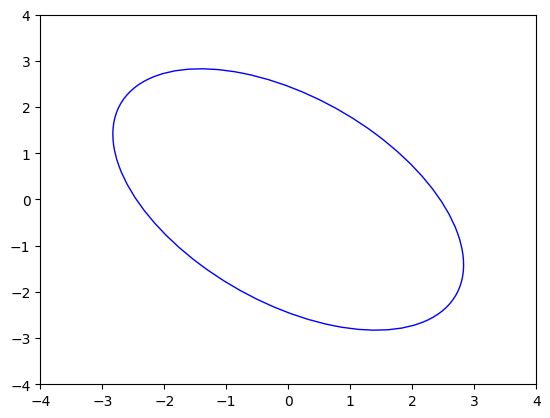

In [158]:
from matplotlib.patches import Ellipse

def plot_ellipse(c1,c2,c3,c4,x_lim,y_lim):
    if is_ellipse(c1, c2, c3, c4):
        plt.figure()
        ax = plt.gca()
        ax.add_artist(Ellipse(
            xy=(0,0),
            width=get_width(c1, c2, c3, c4),
            height=get_height(c1, c2, c3, c4),
            angle=angle_ellipse(c1, c2, c2, c4),
            fill=False, color='b'
        ))
        ax.set_xlim(-x_lim, x_lim)
        ax.set_ylim(-y_lim, y_lim)
        plt.show()

plot_ellipse(1,1,1,6,4,4)

Here are two more plots of ellipses using the functions you previously implemented.

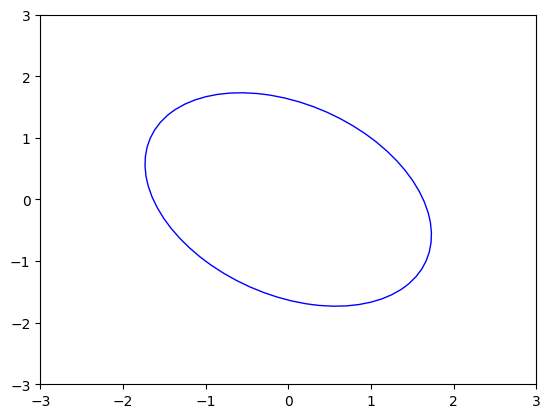

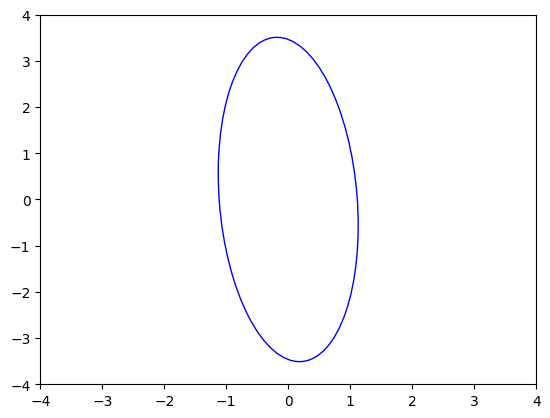

In [159]:
plot_ellipse(3,3,-2,8,3,3)
plot_ellipse(29,3,3,36,4,4)

#### Note:

From this point, all the remaining exercises are bonus.


## Part 3: Plotting an horizontal hyperbola

Unlike for the ellipse, there is no module providing us an Hyperbola class. So we will ''patch together'' four graphs of functions (each graph is then plotted using the regular `plt.plot` function). In the picture below, you can see each graph in a different color.

![Screenshot%20from%202023-02-06%2008-31-59.png](attachment:Screenshot%20from%202023-02-06%2008-31-59.png)

Even though we will not proceed like in the case of the ellipse, we will still need the parameters of the hyperbola in order to plot it. In particular, we will need to compute the coordinates of its vertices $(a,0)$ and $(-a,0)$ (in the new coordinate system) and the coefficient $b$ such that the lines $y =\frac{b}{a}x$ and $y =\frac{-b}{a}x$ are the asymptotes of the hyperbola (in the new coordinate system).

![horiz_hyperbola.png](attachment:horiz_hyperbola.png)

### Bonus 7 (0.25 pt): Computing the parameters of the hyperbola

We ask you to implement first the functions `get_horiz_vertex(c1, c2, c3, c4)` and  `get_horiz_b(c1, c2, c3, c4)` such that
* `get_horiz_vertex(c1, c2, c3, c4)` returns the coefficient $a$,

* `get_horiz_b(c1, c2, c3, c4)` returns the coefficient $b$,

where
$$
 \frac{x'^2}{a^2} - \frac{y'^2}{b^2} =1
$$
is the canonical equation in the new coordinate system, of the hyberbola associated with the equation $c_1 x^2 + c_2 y^2 + c_3 xy  = c_4$.

Hint. In the new coordinate system, the equation of the hyperbola is
$
\lambda_1 x'^2 + \lambda_2y'^2 = c_4
$, where $\lambda_1$ and $\lambda_2$ are the eigenvalues of the matrix associated with $c_1 x^2 + c_2 y^2 + c_3 xy$. This equation is equivalent to
$$
\frac{x'^2}{\frac{c_4}{\lambda_1}} - \frac{y'^2}{\frac{c_4}{\lambda_2}} =1
$$
The function `get_eigenvalues` that you defined earlier, might also be helpful to define `get_horiz_vertex` and `get_horiz_b`.

In [160]:
def get_horiz_vertex(c1, c2, c3, c4):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    pass

def get_horiz_b(c1, c2, c3, c4):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    pass

You can run the cell below to test your code.

In [161]:
# assert np.isclose(get_horiz_vertex(4,-4,6,5), 1), 'Basic test failed'

print('Function seems to work')

Function seems to work


### Bonus 8 (0.25 pt): Rotating the graph of a function

Now that we can compute the coefficients $a$ and $b$, it would be easy to plot the hyperbola in the new coordinate system. However, this new coordinate system is obtained applyting a rotation to the ''old'' coordinate system. So we should be able to apply a rotation to the graph of a function.

We ask you to implement a function `plot_rotated_graph(func, Q, x_min, x_max)` which given a function `func`, a rotation matrix `Q` and an interval `[x_min, x_max]` plots the graph obtained by applying the rotation to the graph of the function `func` over the interval `[x_min, x_max]`.

So for example, if `square` is the square function ($x$ is mapped to $x^2$) and $Q = \begin{bmatrix}0 & -1 \\ 1 & 0 \end{bmatrix}$, then  `plot_rotated_graph(square, Q, -2, 2)` should plot the graph obtained by rotating of $90$ degrees the graph of the function $x^2$ over the interval $[-2,2]$.

![Screenshot%20from%202023-02-06%2009-24-48.png](attachment:Screenshot%20from%202023-02-06%2009-24-48.png)

Hint. This is quite similar to what you did in the first lab when you were rotating the dinosaur.

#### Important:
Notice in the function below the argument `dataset_ax=None`. For now you do not need to use it. This will be of use in a following exercise, where we will want to draw several graphs of functions within the same figure.

In [162]:
def plot_rotated_graph(func, Q, x_min, x_max, dataset_ax=None):
    # Hint: Work using the given variables dataset_fig and dataset_ax. Do NOT change these names.
    # Hint: Do not change this if-else statement.
    if dataset_ax is None:
        dataset_fig, dataset_ax = plt.subplots()
    else:
        dataset_fig = dataset_ax.figure

    # Hint: Use dataset_ax.plot()
    #. Your solution here ...
    pass
    # Hint: Do NOT change the line below.
    return dataset_ax

If your function is correct, when running the cell below, you should see the graph obtained by rotating of $90$ degrees the graph of the function $x^2$ over the interval $[-2,2]$. You can play around (by modifying the inputs for `func` and `Q`) to check the correctness of your function.

<Axes: >

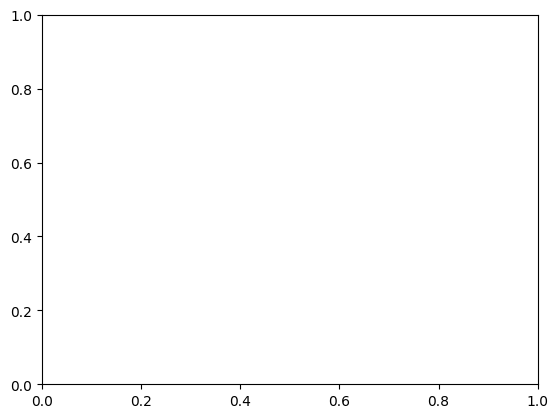

In [163]:
# Compute f(x) = x^2
square = lambda x: x**2

Q = np.array([[0,-1], [1,0]])
plot_rotated_graph(square, Q, -2, 2)

### Bonus 9 (0.25 pt): Plotting a horizontal hyperbola

We can now compute the parameters of an horizontal hyperbola and rotate the graph of a function. This will allow us to finally plot the graph of an horizontal hyperbola. We ask you to implement a function `plot_horiz_hyperbola(c1, c2, c3, c4, x_lim)` plotting the graph of the horizontal hyperbola associated with the equation $c_1 x^2 + c_2 y^2 + c_3 xy = c_4$ over the interval $[-a-x_{\text{lim}}, a+x_{\text{lim}}]$, where $a$ is the coefficient defined in Bonus $7$.

For example, `plot_horiz_hyperbola(4,-4,6,5,5)` would plot the following hyperbola

![Screenshot%20from%202023-02-06%2008-31-59.png](attachment:Screenshot%20from%202023-02-06%2008-31-59.png)

Hint 1. As mentioned at the beginning of Part $3$, we are ''patching together'' four graphs of functions (in the picture above, each graph is of a different colour). Remember that in the new coordinate system, the equation of the hyperbola is of the form $
 \frac{x'^2}{a^2} - \frac{y'^2}{b^2} =1
$, where $a$ and $b$ are the coefficients defined in Bonus $7$. This is equivalent to
$$
y'^2 = \frac{b^2x'^2}{a^2}- b^2
$$
This equation has two solutions:
$$
f_1(x') = \sqrt{\frac{b^2x'^2}{a^2}- b^2},  \quad f_2(x') = -\sqrt{\frac{b^2x'^2}{a^2}- b^2}
$$

So if we look for example at the graph in blue (the graph at top right corner of the picture), it is the graph of the function
$f_1(x')$
 over the interval $[a, a+x_{\text{lim}}]$,
while the graph in green is the graph of $f_1(x')$ over the interval $[-a-x_{\text{lim}}, a]$. The graph in orange is the graph of the function $f_2(x') $
over the interval $[a, a+x_{\text{lim}}]$ and the graph in red is the graph of $f_2(x')$ over the interval $[-a-x_{\text{lim}}, a]$.

We can use `plt.plot` to plot those four graphs but as mentioned earlier, we need to apply a rotation (described by the matrix $Q$) to those four graphs. This is where you will need to use the function `plot_rotated_graph` that you defined earlier.

Hint 2. As you have seen, the input `func` of `plot_rotated_graph` is a function. So you can use a function as an input for another function. You can use the usual keyword `def func(x): ...` in order to define `func`. But a cleaner/better way would be to use a [lambda function](https://www.w3schools.com/python/python_lambda.asp), which is an anonymous function you can easily define in one line. You can make the assignment without using lamba functions, but in case you know how to use lambda functions or you are interested to learn about them via the small linked tutorial, this might be a good opportunity.

#### Important:
Now we can utilize the argument `dataset_ax` in the `plot_rotated_graph`. You can use it to plot incrementally in the same figure.

In [164]:
def plot_horiz_hyperbola(c1, c2, c3, c4, x_lim):
    #. Your solution here ...
    pass

If all your previous functions are correct, `plot_horiz_hyperbola(4,-4,6,5,5)` should now be identical to the plot shown directly above. You have also drawn this hyperbola that you during the werkcollege (exercise $5.5.53$).

In [165]:
plot_horiz_hyperbola(4,-4,6,5,5)

## Part 4: Plotting a vertical hyperbola

Now that we know how to plot an horizontal hyperbola, it should be easy to modify our functions, so that we can plot a vertical hyperbola.

### Bonus 10 (0.25 pt): Computing the parameters of a vertical hyperbola

Similarly to the previous case, we ask you to implement first the functions `get_vert_vertex(c1, c2, c3, c4)` and  `get_vert_b(c1, c2, c3, c4` such that
* `get_vert_vertex(c1, c2, c3, c4)` returns the coefficient $a$,

* `get_vert_b(c1, c2, c3, c4)` returns the coefficient $b$,

where
$$
 -\frac{x'^2}{a^2} + \frac{y'^2}{b^2} =1
$$
is the canonical equation in the new coordinate system, of the hyberbola associated with the equation $c_1 x^2 + c_2 y^2 + c_3 xy  = c_4$.

In [166]:
def get_vert_vertex(c1, c2, c3, c4):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    pass

def get_vert_b(c1, c2, c3, c4):
    # Hint: Return a value. Do NOT deviate from this.
    #. Your solution here ...
    pass

You can run the cell below to test your code.

In [167]:
# assert np.isclose(get_vert_vertex(-4,4,6,5), 1), 'Basic test failed'
# assert np.isclose(get_vert_b(-4,4,6,5), 1), 'Basic test failed'

print('Functions seem to work')

Functions seem to work


### Bonus 11 (0.25 pt): plotting a vertical hyperbola

We finally ask you to implement a function `plot_vert_hyperbola(c1, c2, c3, c4, x_lim)` plotting the vertical hyperbola associated with the equation $c_1 x^2 + c_2 y^2 + c_3^2 xy  = c_4$, over the interval `[-x_lim, x_lim]`. Note that this function should be an easy adapation of the function `plot_horiz_hyperbola` and in particular, you probably want to use the function `plot_rotated_graph`.

In [168]:
def plot_vert_hyperbola(c1, c2, c3, c4, x_lim):
    #. Your solution here ...
    pass

If your function is correct, `plot_vert_hyperbola(-4,4,6,5,5)` should now plot the following hyperbola:

In [169]:
plot_vert_hyperbola(-4,4,6,5,5)

## Part 5: Plotting an arbitrary conic

Now that we know how to plot each type of conic, we can use all of our functions to be able to plot an arbitrary quadratic form.

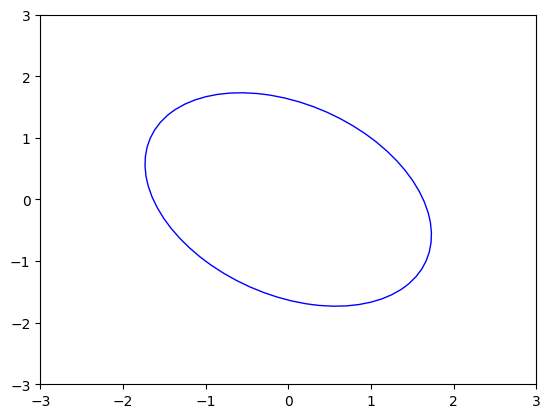

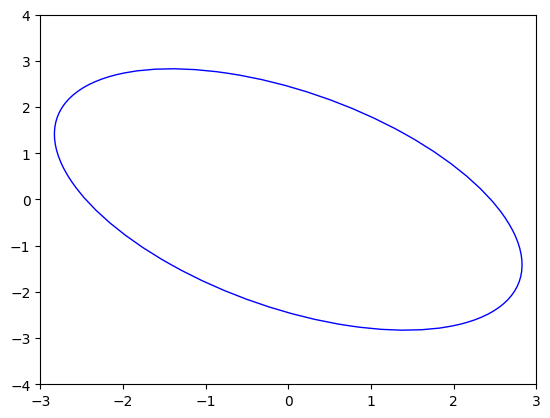

In [170]:
def plot_conics(c1,c2,c3,c4, x_lim, y_lim):
    if is_ellipse(c1,c2,c3,c4):
        plot_ellipse(c1,c2,c3,c4, x_lim, y_lim)

    elif is_horiz_hyperbola(c1,c2,c3,c4):
        plot_horiz_hyperbola(c1,c2,c3,c4,x_lim)

    elif is_vert_hyperbola(c1,c2,c3,c4):
        plot_vert_hyperbola(c1,c2,c3,c4,x_lim)

# These should plot ellipses!
plot_conics(3,3,-2,8,3,3)
plot_conics(1,1,1,6,3,4)

# Comment these out if you did not do the bonus exercises!
# plot_conics(4,-4,6,5,5,5)
# plot_conics(-4,4,6,5,5,5)
# plot_conics(4,4,10,9,5,5)